## 2. Model Building

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/cleaned_flight_delay_data.csv")

df.head()

,YEAR,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_TIME_BLK,CRS_ARR_TIME,ARR_TIME,ARR_DELAY_NEW,ARR_DEL15,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,DISTANCE,DISTANCE_GROUP,ROUTE
0,2025,1,3,1/1/2025 12:00:00 AM,AA,1,JFK,"New York, NY",LAX,"Los Angeles, CA",659,0600-0659,1020,1013.0,0.0,0,0.0,0.0,381.0,2475.0,10,JFK-LAX
1,2025,1,3,1/1/2025 12:00:00 AM,AA,10,LAX,"Los Angeles, CA",JFK,"New York, NY",2200,2200-2259,630,543.0,0.0,0,0.0,0.0,330.0,2475.0,10,LAX-JFK
2,2025,1,3,1/1/2025 12:00:00 AM,AA,1002,MSN,"Madison, WI",CLT,"Charlotte, NC",644,0600-0659,1005,1025.0,20.0,1,0.0,0.0,141.0,708.0,3,MSN-CLT
3,2025,1,3,1/1/2025 12:00:00 AM,AA,1004,PHL,"Philadelphia, PA",LAS,"Las Vegas, NV",1855,1800-1859,2134,2127.0,0.0,0,0.0,0.0,339.0,2176.0,9,PHL-LAS
4,2025,1,3,1/1/2025 12:00:00 AM,AA,1005,ORD,"Chicago, IL",PHX,"Phoenix, AZ",830,0800-0859,1131,1215.0,44.0,1,0.0,0.0,241.0,1440.0,6,ORD-PHX


In [4]:
df.shape

(522269, 22)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 522269 entries, 0 to 522268
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   YEAR               522269 non-null  int64  
 1   DAY_OF_MONTH       522269 non-null  int64  
 2   DAY_OF_WEEK        522269 non-null  int64  
 3   FL_DATE            522269 non-null  str    
 4   OP_UNIQUE_CARRIER  522269 non-null  str    
 5   OP_CARRIER_FL_NUM  522269 non-null  int64  
 6   ORIGIN             522269 non-null  str    
 7   ORIGIN_CITY_NAME   522269 non-null  str    
 8   DEST               522269 non-null  str    
 9   DEST_CITY_NAME     522269 non-null  str    
 10  CRS_DEP_TIME       522269 non-null  int64  
 11  DEP_TIME_BLK       522269 non-null  str    
 12  CRS_ARR_TIME       522269 non-null  int64  
 13  ARR_TIME           522269 non-null  float64
 14  ARR_DELAY_NEW      522269 non-null  float64
 15  ARR_DEL15          522269 non-null  int64  
 16  CANCELLED    

## 1. Selecting Features and Target

In [7]:
features = [
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "CRS_DEP_TIME",
    "DEP_TIME_BLK",
    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE",
    "DISTANCE_GROUP",
    "ROUTE"
]

target = "ARR_DEL15"

X = df[features]
y = df[target]

X.head()

,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME_BLK,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,DISTANCE_GROUP,ROUTE
0,1,3,AA,JFK,LAX,659,0600-0659,1020,381.0,2475.0,10,JFK-LAX
1,1,3,AA,LAX,JFK,2200,2200-2259,630,330.0,2475.0,10,LAX-JFK
2,1,3,AA,MSN,CLT,644,0600-0659,1005,141.0,708.0,3,MSN-CLT
3,1,3,AA,PHL,LAS,1855,1800-1859,2134,339.0,2176.0,9,PHL-LAS
4,1,3,AA,ORD,PHX,830,0800-0859,1131,241.0,1440.0,6,ORD-PHX


In [8]:
y.value_counts(normalize=True) * 100

ARR_DEL15
0    81.210832
1    18.789168
Name: proportion, dtype: float64

## 2. Train-test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((417815, 12), (104454, 12))

In [11]:
y_train.value_counts(normalize=True) * 100



ARR_DEL15
0    81.210823
1    18.789177
Name: proportion, dtype: float64

In [14]:
y_test.value_counts(normalize=True) * 100

ARR_DEL15
0    81.210868
1    18.789132
Name: proportion, dtype: float64

## 3. Baseline Model

In [16]:
baseline_model = DummyClassifier(strategy="most_frequent")

baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_preds)
baseline_precision = precision_score(y_test, baseline_preds, zero_division=0)
baseline_recall = recall_score(y_test, baseline_preds, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_preds, zero_division=0)

print("Baseline Model Performance")
print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1 Score:  {baseline_f1:.4f}")

Baseline Model Performance
Accuracy:  0.8121
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000


### Baseline Model Interpretation

The baseline model predicts the majority class for every flight. Since most flights are not delayed, the baseline achieves relatively high accuracy.

However, the precision, recall, and F1 score for the delayed class are 0 because the model never predicts any flight as delayed. This shows why accuracy alone is not enough for this project.

In [17]:
print(classification_report(y_test, baseline_preds))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90     84828
           1       0.00      0.00      0.00     19626

    accuracy                           0.81    104454
   macro avg       0.41      0.50      0.45    104454
weighted avg       0.66      0.81      0.73    104454



c:\Users\Syahid\Documents\GitHub\Projects\Flight_Delay_Prediction_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Syahid\Documents\GitHub\Projects\Flight_Delay_Prediction_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Syahid\Documents\GitHub\Projects\Flight_Delay_Prediction_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.

Although the baseline model achieved 81% accuracy, it failed to identify any delayed flights. This shows that accuracy alone is misleading because the dataset is imbalanced toward non-delayed flights.

## 4. Logistic Regression Model

In [20]:
numeric_features = [
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE",
    "DISTANCE_GROUP"
]

categorical_features = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_TIME_BLK",
    "ROUTE"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

In [21]:
log_reg_model.fit(X_train, y_train)

c:\Users\Syahid\Documents\GitHub\Projects\Flight_Delay_Prediction_Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [22]:
log_reg_preds = log_reg_model.predict(X_test)

In [23]:
print(classification_report(y_test, log_reg_preds))

              precision    recall  f1-score   support

           0       0.87      0.60      0.71     84828
           1       0.26      0.61      0.36     19626

    accuracy                           0.60    104454
   macro avg       0.56      0.60      0.54    104454
weighted avg       0.75      0.60      0.64    104454



In [24]:
log_reg_accuracy = accuracy_score(y_test, log_reg_preds)
log_reg_precision = precision_score(y_test, log_reg_preds)
log_reg_recall = recall_score(y_test, log_reg_preds)
log_reg_f1 = f1_score(y_test, log_reg_preds)

print("Logistic Regression Performance")
print(f"Accuracy:  {log_reg_accuracy:.4f}")
print(f"Precision: {log_reg_precision:.4f}")
print(f"Recall:    {log_reg_recall:.4f}")
print(f"F1 Score:  {log_reg_f1:.4f}")

Logistic Regression Performance
Accuracy:  0.6002
Precision: 0.2597
Recall:    0.6096
F1 Score:  0.3643


### Logistic Regression Interpretation

The Logistic Regression model performed better than the baseline at identifying delayed flights. While the baseline model had 0 recall for delayed flights, Logistic Regression achieved a recall of around 61% for the delayed class.

However, the model's precision for delayed flights was low, meaning many flights predicted as delayed were not actually delayed. This shows a trade-off: the model is better at catching delays, but it produces many false positives.

The overall accuracy is lower than the baseline, but this does not necessarily mean the model is worse. For this project, recall and F1-score for the delayed class are more important than accuracy alone.

In [25]:
model_results = []

model_results.append({
    "model": "Baseline",
    "accuracy": accuracy_score(y_test, baseline_preds),
    "precision": precision_score(y_test, baseline_preds, zero_division=0),
    "recall": recall_score(y_test, baseline_preds, zero_division=0),
    "f1_score": f1_score(y_test, baseline_preds, zero_division=0)
})

model_results.append({
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, log_reg_preds),
    "precision": precision_score(y_test, log_reg_preds),
    "recall": recall_score(y_test, log_reg_preds),
    "f1_score": f1_score(y_test, log_reg_preds)
})

pd.DataFrame(model_results)

,model,accuracy,precision,recall,f1_score
0,Baseline,0.812109,0.000000,0.0000,0.000000
1,Logistic Regression,0.600207,0.259737,0.6096,0.364267


## 5. Decision Tree Model

In [27]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=10,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [35]:
decision_tree_preds = decision_tree_model.predict(X_test)

print(classification_report(y_test, decision_tree_preds))

              precision    recall  f1-score   support

           0       0.88      0.74      0.81     84828
           1       0.34      0.56      0.42     19626

    accuracy                           0.71    104454
   macro avg       0.61      0.65      0.61    104454
weighted avg       0.78      0.71      0.73    104454



In [30]:
model_results.append({
    "model": "Decision Tree",
    "accuracy": accuracy_score(y_test, decision_tree_preds),
    "precision": precision_score(y_test, decision_tree_preds),
    "recall": recall_score(y_test, decision_tree_preds),
    "f1_score": f1_score(y_test, decision_tree_preds)
})

pd.DataFrame(model_results)

,model,accuracy,precision,recall,f1_score
0,Baseline,0.812109,0.000000,0.000000,0.000000
1,Logistic Regression,0.600207,0.259737,0.609600,0.364267
2,Decision Tree,0.709374,0.335711,0.558647,0.419394


### Decision Tree Interpretation

The Decision Tree model performed better than Logistic Regression in terms of accuracy, precision, and F1-score for delayed flights.

Compared to Logistic Regression, the Decision Tree had slightly lower recall for delayed flights, meaning it missed more actual delays. However, it had better precision, meaning its delay predictions were more reliable.

Overall, the Decision Tree provides a better balance between identifying delayed flights and reducing false positives.

## 6. Random Forest Model

In [32]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=50,
            max_depth=15,
            min_samples_leaf=50,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [34]:
random_forest_preds = random_forest_model.predict(X_test)

print(classification_report(y_test, random_forest_preds))

              precision    recall  f1-score   support

           0       0.87      0.59      0.70     84828
           1       0.26      0.62      0.37     19626

    accuracy                           0.60    104454
   macro avg       0.57      0.61      0.54    104454
weighted avg       0.76      0.60      0.64    104454



In [36]:
model_results.append({
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, random_forest_preds),
    "precision": precision_score(y_test, random_forest_preds),
    "recall": recall_score(y_test, random_forest_preds),
    "f1_score": f1_score(y_test, random_forest_preds)
})

model_results_df = pd.DataFrame(model_results)
model_results_df

,model,accuracy,precision,recall,f1_score
0,Baseline,0.812109,0.000000,0.000000,0.000000
1,Logistic Regression,0.600207,0.259737,0.609600,0.364267
2,Decision Tree,0.709374,0.335711,0.558647,0.419394
3,Random Forest,0.596732,0.260431,0.623051,0.367323


In [37]:
model_results_df.to_csv("../results/model_comparison.csv", index=False)

## 7. Graidient Boosting

In [43]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ]
)

gradient_boosting_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [44]:
gradient_boosting_preds = gradient_boosting_model.predict(X_test)

print(classification_report(y_test, gradient_boosting_preds))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90     84828
           1       0.72      0.01      0.03     19626

    accuracy                           0.81    104454
   macro avg       0.77      0.51      0.46    104454
weighted avg       0.80      0.81      0.73    104454



### Gradient Boosting Interpretation

The Gradient Boosting model achieved high overall accuracy, but it performed poorly for the delayed class. Its recall for delayed flights was close to zero, meaning it missed almost all actual delayed flights.

Although its precision for delayed predictions was high, this is not very useful because the model predicted very few flights as delayed. For this project, the model needs to identify delayed flights reasonably well, so Gradient Boosting is not selected as the best model.

In [45]:
model_results.append({
    "model": "Gradient Boosting",
    "accuracy": accuracy_score(y_test, gradient_boosting_preds),
    "precision": precision_score(y_test, gradient_boosting_preds),
    "recall": recall_score(y_test, gradient_boosting_preds),
    "f1_score": f1_score(y_test, gradient_boosting_preds)
})

model_results_df = pd.DataFrame(model_results)
model_results_df

,model,accuracy,precision,recall,f1_score
0,Baseline,0.812109,0.000000,0.000000,0.000000
1,Logistic Regression,0.600207,0.259737,0.609600,0.364267
2,Decision Tree,0.709374,0.335711,0.558647,0.419394
3,Random Forest,0.596732,0.260431,0.623051,0.367323
4,Gradient Boosting,0.813679,0.718085,0.013757,0.026997


## 8. Tuned Decision Tree Model

In [46]:
decision_tree_tuned = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=15,
            min_samples_leaf=100,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

decision_tree_tuned.fit(X_train, y_train)

decision_tree_tuned_preds = decision_tree_tuned.predict(X_test)

print(classification_report(y_test, decision_tree_tuned_preds))

              precision    recall  f1-score   support

           0       0.89      0.72      0.79     84828
           1       0.33      0.61      0.43     19626

    accuracy                           0.70    104454
   macro avg       0.61      0.66      0.61    104454
weighted avg       0.78      0.70      0.73    104454



### Tuned Decision Tree Interpretation

The tuned Decision Tree achieved the best F1-score for the delayed class so far. Compared to the original Decision Tree, it had slightly lower precision but higher recall, meaning it identified more actual delayed flights.

Although the overall accuracy decreased slightly, this model is more useful for the project because it performs better at detecting 

In [47]:
model_results_df = pd.DataFrame(model_results)

model_results_df.sort_values("f1_score", ascending=False)

,model,accuracy,precision,recall,f1_score
2,Decision Tree,0.709374,0.335711,0.558647,0.419394
3,Random Forest,0.596732,0.260431,0.623051,0.367323
1,Logistic Regression,0.600207,0.259737,0.609600,0.364267
4,Gradient Boosting,0.813679,0.718085,0.013757,0.026997
0,Baseline,0.812109,0.000000,0.000000,0.000000


In [48]:
model_results_df.to_csv("../results/model_comparison.csv", index=False)

## 10. Decision Tree Hyperparameter Tuning

In [52]:
from sklearn.model_selection import GridSearchCV

dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

param_grid = {
    "classifier__max_depth": [10, 15, 20],
    "classifier__min_samples_leaf": [50, 100, 200],
    "classifier__min_samples_split": [100, 200]
}

grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [10, 15, ...], 'classifier__min_samples_leaf': [50, 100, ...], 'classifier__min_samples_split': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [53]:
grid_search.best_params_

{'classifier__max_depth': 15,
 'classifier__min_samples_leaf': 50,
 'classifier__min_samples_split': 200}

In [54]:
grid_search.best_score_

np.float64(0.4232601287180686)

In [55]:
best_dt_model = grid_search.best_estimator_

best_dt_preds = best_dt_model.predict(X_test)

print(classification_report(y_test, best_dt_preds))

              precision    recall  f1-score   support

           0       0.89      0.73      0.80     84828
           1       0.34      0.60      0.43     19626

    accuracy                           0.70    104454
   macro avg       0.61      0.67      0.62    104454
weighted avg       0.78      0.70      0.73    104454



In [56]:
model_results.append({
    "model": "GridSearch Tuned Decision Tree",
    "accuracy": accuracy_score(y_test, best_dt_preds),
    "precision": precision_score(y_test, best_dt_preds),
    "recall": recall_score(y_test, best_dt_preds),
    "f1_score": f1_score(y_test, best_dt_preds)
})

model_results_df = pd.DataFrame(model_results)
model_results_df.sort_values("f1_score", ascending=False)

,model,accuracy,precision,recall,f1_score
5,GridSearch Tuned Decision Tree,0.702568,0.337416,0.604963,0.433210
2,Decision Tree,0.709374,0.335711,0.558647,0.419394
3,Random Forest,0.596732,0.260431,0.623051,0.367323
1,Logistic Regression,0.600207,0.259737,0.609600,0.364267
4,Gradient Boosting,0.813679,0.718085,0.013757,0.026997
0,Baseline,0.812109,0.000000,0.000000,0.000000


In [58]:
model_results_df.to_csv("../results/model_comparison.csv", index=False)

### GridSearch Tuned Decision Tree Interpretation

The GridSearch tuned Decision Tree produced similar performance to the manually tuned Decision Tree. It achieved an F1-score of around 0.43 for delayed flights, with a precision of 0.34 and recall of 0.60.

This means the model identified around 60% of actual delayed flights, but many predicted delays were still false positives. Compared to the baseline model, the tuned Decision Tree is more useful because it can detect delayed flights instead of simply predicting every flight as not delayed.

The improvement from hyperparameter tuning was limited, suggesting that the available features may not fully capture the causes of flight delays.

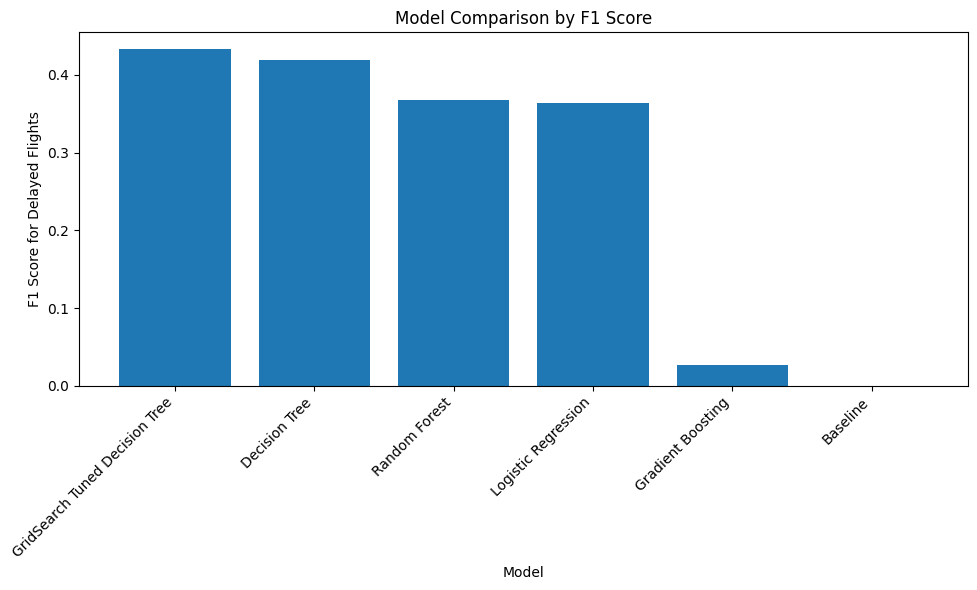

In [59]:
model_results_df_sorted = model_results_df.sort_values("f1_score", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(model_results_df_sorted["model"], model_results_df_sorted["f1_score"])
plt.title("Model Comparison by F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score for Delayed Flights")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../charts/model_f1_comparison.png", dpi=300)
plt.show()

## 11. Confusion Matrix for Best Model

In [ ]:
best_model_preds = best_dt_preds

cm = confusion_matrix(y_test, best_model_preds)

cm

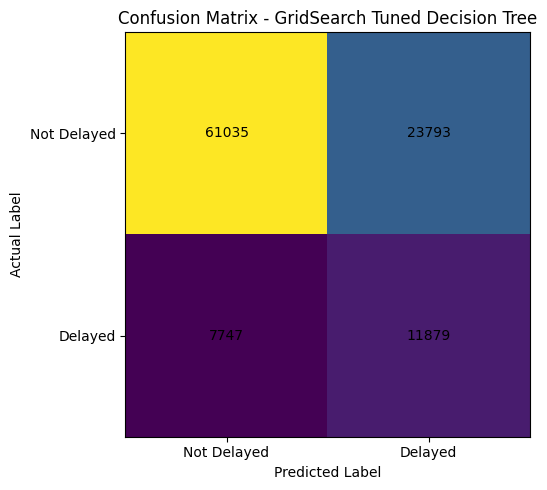

In [60]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - GridSearch Tuned Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Not Delayed", "Delayed"])
plt.yticks([0, 1], ["Not Delayed", "Delayed"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("../charts/confusion_matrix_best_model.png", dpi=300)
plt.show()

### Confusion Matrix Interpretation

The best model correctly identified 11,879 delayed flights and 61,035 non-delayed flights.

However, it also produced 23,793 false positives, where flights were predicted as delayed but were not actually delayed. It also missed 7,747 actual delayed flights.

This means the model was able to identify around 60% of delayed flights, but many of its delay predictions were false alarms. Therefore, the model is more useful as a delay-risk screening tool than as a highly precise prediction system.

## 12. Feature Importance

In [61]:
best_dt_model = grid_search.best_estimator_

feature_names = best_dt_model.named_steps["preprocessor"].get_feature_names_out()

importances = best_dt_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
6321,num__DAY_OF_MONTH,0.389944
6322,num__DAY_OF_WEEK,0.096622
6323,num__CRS_DEP_TIME,0.095333
12,cat__OP_UNIQUE_CARRIER_WN,0.038729
6326,num__DISTANCE,0.034846
6324,num__CRS_ARR_TIME,0.030004
96,cat__ORIGIN_DEN,0.029119
6325,num__CRS_ELAPSED_TIME,0.023067
31,cat__ORIGIN_ATL,0.019115
425,cat__DEST_DEN,0.014311


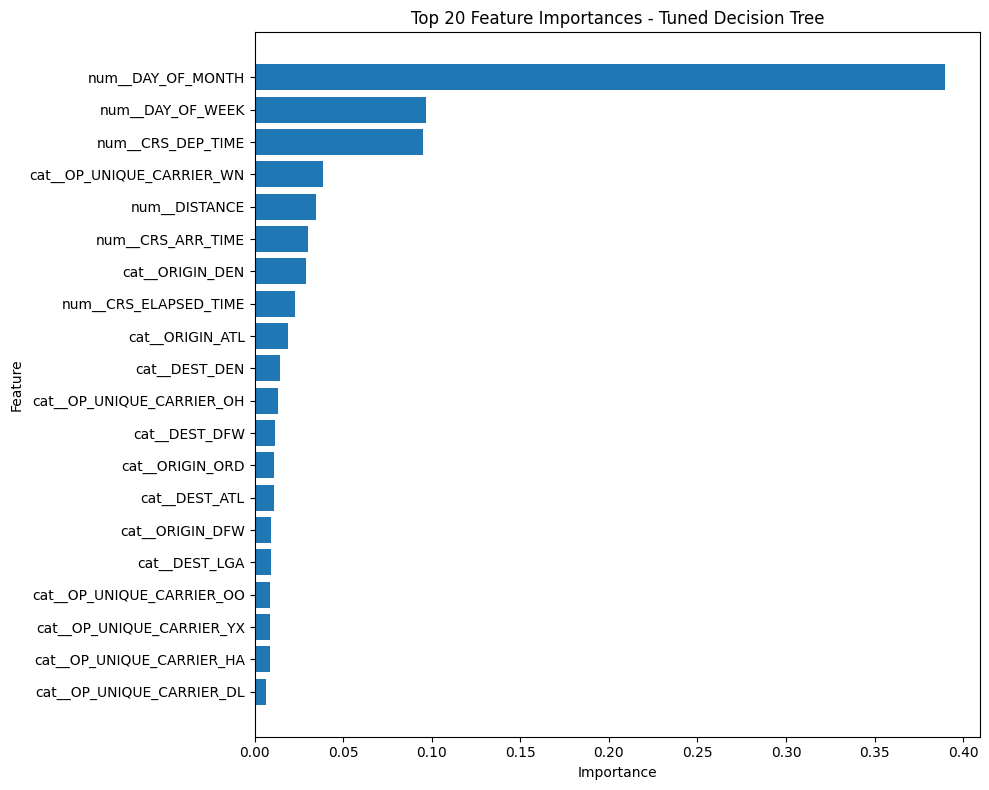

In [62]:
top_features = feature_importance_df.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 20 Feature Importances - Tuned Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../charts/feature_importance_best_model.png", dpi=300)
plt.show()

In [63]:
feature_importance_df.to_csv("../results/feature_importance.csv", index=False)

### Feature Importance Interpretation

The tuned Decision Tree relied most heavily on `DAY_OF_MONTH`, followed by `DAY_OF_WEEK`, scheduled departure time, airline, distance, scheduled arrival time, and selected origin/destination airports.

The high importance of `DAY_OF_MONTH` suggests that date-specific factors may strongly influence delay risk in this January 2025 dataset. This could reflect weather disruptions, holiday travel patterns, or other temporary operational issues.

This is an important limitation because patterns learned from one month may not fully generalise to other months. Future versions of this project should include multiple months of data to improve generalisability.